# ⚙️ Basic Setup


In [1]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
# ── 나눔고딕 폰트 설치 (최초 1회, 이후 주석 처리 가능) ──────────────
!sudo apt-get install -y -qq fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── 한국어 폰트 설정 ──────────────────────────────────────────
import matplotlib.font_manager as fm
font_dirs = ['/usr/share/fonts/truetype/nanum']
font_files = fm.findSystemFonts(fontpaths=font_dirs)
for ff in font_files:
    fm.fontManager.addfont(ff)
plt.rcParams['font.family'] = 'NanumBarunGothic'
plt.rcParams['axes.unicode_minus'] = False

# ── Wilke 스타일: 흰 배경, 최소 격자, 고해상도 ────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
    'axes.facecolor': '#FAFAFA',
})

# ── 브랜드 색상 팔레트 (고정) ─────────────────────────────────
BRAND_COLORS = {
    'SK에너지':    '#E63946',
    'GS칼텍스':   '#457B9D',
    'S-OIL':      '#F4A261',
    '현대오일뱅크': '#2A9D8F',
    '알뜰주유소':  '#6D6875',
    '알뜰(ex)':   '#B5838D',
    'NH-OIL':     '#8338EC',
    '자가상표':    '#3A86FF',
    'NC오일':      '#FB5607',
    'SK가스':      '#FFBE0B',
}

print(" 환경 설정 완료")
print(f"   사용 폰트: {plt.rcParams['font.family']}")


 환경 설정 완료
   사용 폰트: ['NanumBarunGothic']


# (Unused) 💻 Data Integration & Coordinate Conversion for Google Colab


In [ ]:
from google.colab import drive
import pandas as pd
import os
import requests
import time
import unicodedata

# 1. 드라이브 마운트
drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
output_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")
api_key = "YOUR_VWORLD_API_KEY" # Vworld API 키 입력

print("1. 파일 데이터 로드 및 정렬을 시작합니다...")

if not os.path.exists(base_path):
    print(f"❌ [오류] 경로를 찾을 수 없습니다: {base_path}")
else:
    all_files = os.listdir(base_path)
    file_list = []

    # 2. 'CSV 파일'만 엄격하게 탐색
    for f in all_files:
        norm_f = unicodedata.normalize('NFC', f)
        if '상업업무' in norm_f and norm_f.lower().endswith('.csv') and f != "상업업무_실거래가_통합_좌표완료.csv":
            file_list.append(os.path.join(base_path, f))

    # [중요] 매번 동일한 데이터 순서를 보장하기 위해 파일 목록 정렬
    file_list.sort()

    if len(file_list) == 0:
        print("❌ [중단] 로드할 수 있는 CSV 파일이 없습니다.")
    else:
        df_list = []
        for file in file_list:
            encoding_to_use = 'cp949'
            try:
                try:
                    with open(file, 'r', encoding='cp949') as f:
                        lines = f.readlines()
                except UnicodeDecodeError:
                    encoding_to_use = 'utf-8'
                    with open(file, 'r', encoding='utf-8') as f:
                        lines = f.readlines()

                header_idx = 0
                for i, line in enumerate(lines[:30]):
                    if '시군구' in line and '거래금액' in line:
                        header_idx = i
                        break

                temp_df = pd.read_csv(file, encoding=encoding_to_use, skiprows=header_idx)
                df_list.append(temp_df)
            except Exception as e:
                print(f" - [실패] 읽기 오류: {e}")

        # 3. 데이터 병합 및 중복 제거
        if len(df_list) > 0:
            raw_df = pd.concat(df_list, ignore_index=True)

            target_columns = ['시군구', '유형', '지번', '도로명', '건축물주용도', '전용/연면적(㎡)', '거래금액(만원)', '계약년월', '계약일']
            available_columns = [col for col in target_columns if col in raw_df.columns]
            df = raw_df[available_columns].copy()

            dedup_subset = [col for col in ['시군구', '지번', '계약년월', '계약일', '전용/연면적(㎡)', '거래금액(만원)'] if col in df.columns]
            df.drop_duplicates(subset=dedup_subset, inplace=True)
            df.reset_index(drop=True, inplace=True) # 인덱스 초기화 (이어하기 기준점)

            if '거래금액(만원)' in df.columns:
                df['거래금액(만원)'] = df['거래금액(만원)'].astype(str).str.replace(',', '').astype(float)

            def refine_address(row):
                sigungu = str(row.get('시군구', '')) if pd.notna(row.get('시군구')) else ""
                doromyung = str(row.get('도로명', '')) if pd.notna(row.get('도로명')) else ""
                jibun = str(row.get('지번', '')) if pd.notna(row.get('지번')) else ""

                if doromyung.strip() and doromyung != '-':
                    return sigungu + " " + doromyung
                elif jibun.strip() and jibun != '-':
                    clean_jibun = jibun.replace('*', '').strip()
                    if clean_jibun:
                        return sigungu + " " + clean_jibun
                return sigungu

            df['검색용주소'] = df.apply(refine_address, axis=1)
            total_len = len(df)

            # =====================================================================
            # 🚨 [이어하기 로직 구현] 기존 파일 점검 및 시작 인덱스(start_idx) 설정
            # =====================================================================
            print(f"\n▶ 총 변환 대상 데이터: {total_len:,}건")

            if os.path.exists(output_file):
                existing_df = pd.read_csv(output_file, encoding='cp949')
                if len(existing_df) >= total_len:
                    print("✅ 이미 모든 데이터(좌표) 변환이 완료되었습니다. 작업을 중단합니다.")
                    start_idx = total_len
                else:
                    # 사용자 요청 반영: 불완전할 수 있는 마지막 행 삭제
                    existing_df = existing_df.iloc[:-1]
                    start_idx = len(existing_df)

                    # 삭제된 상태로 파일 덮어쓰기 (무결성 확보)
                    existing_df.to_csv(output_file, index=False, encoding='cp949')
                    print(f"⚠️ 기존 작업 내역 발견! 안전을 위해 마지막 행을 삭제했습니다.")
                    print(f"🚀 {start_idx + 1}번째 데이터부터 이어하기를 시작합니다...\n")
            else:
                # 파일이 없을 경우: 헤더가 포함된 빈 파일 생성
                start_idx = 0
                df_empty = df.iloc[0:0].copy()
                df_empty['위도'] = []
                df_empty['경도'] = []
                df_empty.to_csv(output_file, index=False, encoding='cp949')
                print("새로운 파일을 생성하고 처음부터 변환을 시작합니다.\n")

            # =====================================================================
            # 4. 지오코딩 및 실시간 1줄 추가(Append) 저장
            # =====================================================================
            def get_coordinates(address):
                url = f"https://api.vworld.kr/req/address?service=address&request=getcoord&version=2.0&crs=epsg:4326&address={address}&type=ROAD&key={api_key}"
                try:
                    response = requests.get(url)
                    if response.status_code == 200:
                        data = response.json()
                        if data['response']['status'] == 'OK':
                            return float(data['response']['result']['point']['y']), float(data['response']['result']['point']['x'])
                        else:
                            url_parcel = url.replace("type=ROAD", "type=PARCEL")
                            resp_p = requests.get(url_parcel).json()
                            if resp_p['response']['status'] == 'OK':
                                return float(resp_p['response']['result']['point']['y']), float(resp_p['response']['result']['point']['x'])
                except:
                    pass
                return None, None

            if start_idx < total_len:
                print("2. Vworld API 좌표 변환 (실시간 저장 중...)")

                for idx in range(start_idx, total_len):
                    # 1줄짜리 데이터프레임 추출
                    row_df = df.iloc[[idx]].copy()
                    address = row_df['검색용주소'].values[0]

                    lat, lng = get_coordinates(address)
                    row_df['위도'] = lat
                    row_df['경도'] = lng

                    # 파일 끝에 1줄씩 헤더 없이 실시간 추가 (Append mode)
                    row_df.to_csv(output_file, mode='a', header=False, index=False, encoding='cp949')

                    time.sleep(0.1)
                    if (idx + 1) % 100 == 0:
                        print(f" - {idx + 1:,} / {total_len:,}건 완료...")

                print(f"\n✅ 최종 작업 완료! 모든 데이터가 저장되었습니다: {output_file}")
        else:
            print("❌ 로드할 수 있는 유효한 데이터가 없습니다.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. 파일 데이터 로드 및 정렬을 시작합니다...

▶ 총 변환 대상 데이터: 32,124건
새로운 파일을 생성하고 처음부터 변환을 시작합니다.

2. Vworld API 좌표 변환 (실시간 저장 중...)
 - 100 / 32,124건 완료...
 - 200 / 32,124건 완료...
 - 300 / 32,124건 완료...
 - 400 / 32,124건 완료...
 - 500 / 32,124건 완료...
 - 600 / 32,124건 완료...
 - 700 / 32,124건 완료...
 - 800 / 32,124건 완료...
 - 900 / 32,124건 완료...
 - 1,000 / 32,124건 완료...
 - 1,100 / 32,124건 완료...
 - 1,200 / 32,124건 완료...
 - 1,300 / 32,124건 완료...
 - 1,400 / 32,124건 완료...
 - 1,500 / 32,124건 완료...
 - 1,600 / 32,124건 완료...
 - 1,700 / 32,124건 완료...
 - 1,800 / 32,124건 완료...
 - 1,900 / 32,124건 완료...
 - 2,000 / 32,124건 완료...
 - 2,100 / 32,124건 완료...
 - 2,200 / 32,124건 완료...
 - 2,300 / 32,124건 완료...
 - 2,400 / 32,124건 완료...
 - 2,500 / 32,124건 완료...
 - 2,600 / 32,124건 완료...
 - 2,700 / 32,124건 완료...
 - 2,800 / 32,124건 완료...
 - 2,900 / 32,124건 완료...
 - 3,000 / 32,124건 완료...
 - 3,100 / 32,124건 완료..

Resuming Data Merge and Coordinate Calculation Code


In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import os
import requests
import time
import unicodedata
import concurrent.futures # 병렬 처리를 위한 라이브러리 추가

# 1. 기본 설정 및 데이터 로드 (이전과 동일)
drive.mount('/content/drive')
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
output_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")
api_key = "YOUR_VWORLD_API_KEY"

print("1. 데이터를 불러오고 이전 작업 내역을 확인합니다...")

all_files = [os.path.join(base_path, f) for f in os.listdir(base_path)
             if '상업업무' in unicodedata.normalize('NFC', f)
             and f.lower().endswith('.csv') and f != "상업업무_실거래가_통합_좌표완료.csv"]
file_list = sorted(all_files)

df_list = []
for file in file_list:
    encoding_to_use = 'cp949'
    try:
        try:
            with open(file, 'r', encoding='cp949') as f: lines = f.readlines()
        except UnicodeDecodeError:
            encoding_to_use = 'utf-8'
            with open(file, 'r', encoding='utf-8') as f: lines = f.readlines()

        header_idx = next(i for i, line in enumerate(lines[:30]) if '시군구' in line and '거래금액' in line)
        df_list.append(pd.read_csv(file, encoding=encoding_to_use, skiprows=header_idx))
    except: pass

master_df = pd.concat(df_list, ignore_index=True)
available_columns = [col for col in ['시군구', '유형', '지번', '도로명', '건축물주용도', '전용/연면적(㎡)', '거래금액(만원)', '계약년월', '계약일'] if col in master_df.columns]
master_df = master_df[available_columns].copy()

dedup_subset = [col for col in ['시군구', '지번', '계약년월', '계약일', '전용/연면적(㎡)', '거래금액(만원)'] if col in master_df.columns]
master_df.drop_duplicates(subset=dedup_subset, inplace=True)
master_df.reset_index(drop=True, inplace=True)
if '거래금액(만원)' in master_df.columns:
    master_df['거래금액(만원)'] = master_df['거래금액(만원)'].astype(str).str.replace(',', '').astype(float)

def refine_address(row):
    sigungu, doromyung, jibun = str(row.get('시군구', '')), str(row.get('도로명', '')), str(row.get('지번', ''))
    if doromyung.strip() and doromyung != 'nan' and doromyung != '-': return sigungu + " " + doromyung
    elif jibun.strip() and jibun != 'nan' and jibun != '-': return sigungu + " " + jibun.replace('*', '').strip()
    return sigungu

master_df['검색용주소'] = master_df.apply(refine_address, axis=1)
master_df['위도'], master_df['경도'] = np.nan, np.nan
total_len = len(master_df)

# 기존 작업 내역(7,200건 등) 덮어쓰기
if os.path.exists(output_file):
    try:
        df_saved = pd.read_csv(output_file, encoding='cp949')
        if pd.isna(df_saved.iloc[-1]['시군구']): df_saved = df_saved.iloc[:-1]
        master_df.update(df_saved[['위도', '경도']])
    except: pass

missing_mask = master_df['위도'].isna()
if not missing_mask.any():
    print("✅ 모든 좌표의 변환 및 검증이 완료되었습니다.")
else:
    start_idx = missing_mask.idxmax()
    print(f"\n🚀 기존 저장 내역 인식 완료! {start_idx:,}번 데이터부터 '고속 병렬 변환'을 재개합니다.\n")

    # =====================================================================
    # [핵심] 멀티스레딩(Multi-threading) 고속 처리 로직
    # =====================================================================
    def fetch_coord(idx, address):
        url = f"https://api.vworld.kr/req/address?service=address&request=getcoord&version=2.0&crs=epsg:4326&address={address}&type=ROAD&key={api_key}"
        try:
            resp = requests.get(url, timeout=5).json()
            if resp.get('response', {}).get('status') == 'OK':
                return idx, float(resp['response']['result']['point']['y']), float(resp['response']['result']['point']['x'])

            url_parcel = url.replace("type=ROAD", "type=PARCEL")
            resp_p = requests.get(url_parcel, timeout=5).json()
            if resp_p.get('response', {}).get('status') == 'OK':
                return idx, float(resp_p['response']['result']['point']['y']), float(resp_p['response']['result']['point']['x'])
        except: pass
        return idx, None, None

    print("2. Vworld API 10중 다중 요청(병렬)을 시작합니다. 🚀")

    # 100건씩 묶어서 동시에 처리 (안정성을 위해 배치 단위 저장)
    batch_size = 100
    max_workers = 10 # 동시에 보낼 요청 수 (기존 1건 -> 10건)

    start_time = time.time()

    for i in range(start_idx, total_len, batch_size):
        batch_indices = range(i, min(i + batch_size, total_len))

        # 10개의 스레드를 열어 한 번에 주소 좌표를 긁어옵니다
        with concurrent.futures.ThreadPoolExecutor(max_workers=max_workers) as executor:
            futures = [executor.submit(fetch_coord, idx, master_df.at[idx, '검색용주소']) for idx in batch_indices]
            for future in concurrent.futures.as_completed(futures):
                idx, lat, lng = future.result()
                master_df.at[idx, '위도'] = lat
                master_df.at[idx, '경도'] = lng

        # 100건 단위로 드라이브에 안전하게 저장
        master_df.to_csv(output_file, index=False, encoding='cp949')

        current_time = time.time()
        elapsed = current_time - start_time
        print(f" ⚡ {min(i + batch_size, total_len):,} / {total_len:,}건 고속 처리 완료... (누적 소요시간: {elapsed:.1f}초)")

    print(f"\n✅ 초고속 좌표 변환 완료! 최종 파일: {output_file}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
1. 데이터를 불러오고 이전 작업 내역을 확인합니다...

🚀 기존 저장 내역 인식 완료! 0번 데이터부터 '고속 병렬 변환'을 재개합니다.

2. Vworld API 10중 다중 요청(병렬)을 시작합니다. 🚀
 ⚡ 100 / 39,761건 고속 처리 완료... (누적 소요시간: 7.1초)
 ⚡ 200 / 39,761건 고속 처리 완료... (누적 소요시간: 13.7초)
 ⚡ 300 / 39,761건 고속 처리 완료... (누적 소요시간: 20.3초)
 ⚡ 400 / 39,761건 고속 처리 완료... (누적 소요시간: 27.3초)
 ⚡ 500 / 39,761건 고속 처리 완료... (누적 소요시간: 34.0초)
 ⚡ 600 / 39,761건 고속 처리 완료... (누적 소요시간: 40.5초)
 ⚡ 700 / 39,761건 고속 처리 완료... (누적 소요시간: 47.3초)
 ⚡ 800 / 39,761건 고속 처리 완료... (누적 소요시간: 53.9초)
 ⚡ 900 / 39,761건 고속 처리 완료... (누적 소요시간: 61.2초)
 ⚡ 1,000 / 39,761건 고속 처리 완료... (누적 소요시간: 69.8초)
 ⚡ 1,100 / 39,761건 고속 처리 완료... (누적 소요시간: 76.4초)
 ⚡ 1,200 / 39,761건 고속 처리 완료... (누적 소요시간: 82.9초)
 ⚡ 1,300 / 39,761건 고속 처리 완료... (누적 소요시간: 89.7초)
 ⚡ 1,400 / 39,761건 고속 처리 완료... (누적 소요시간: 98.3초)
 ⚡ 1,500 / 39,761건 고속 처리 완료... (누적 소요시간: 105.0초)
 ⚡ 1,600 / 39,761건 고속 처리 완료... (누적 소요시간: 111.5초)
 ⚡

# (Unused) 🧹 [Additional Cell] Duplicate Data Cleansing & Normalization Code
Execute this code right before visualization. It prioritizes valid coordinate data and cleans up redundant duplicates.


In [ ]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
output_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")

print("=== 🧹 중첩 데이터 정리 및 정상화 시작 ===\n")

if not os.path.exists(output_file):
    print("❌ 아직 파일이 없습니다. 변환 작업이 끝날 때까지 기다려주세요.")
else:
    # 1. 부풀려진 데이터 불러오기
    df = pd.read_csv(output_file, encoding='cp949')
    print(f"▶ 정리 전 데이터 건수: {len(df):,}건")

    # 2. 정렬 (매우 중요 ⭐️)
    # 중복된 것들 중 '좌표(위도/경도)가 무사히 채워진 온전한 데이터'를 맨 위로 올립니다.
    df = df.sort_values(by=['위도'], na_position='last')

    # 3. 엄격한 중복 제거 로직 실행
    # 주소, 면적, 금액, 계약일이 모두 동일하면 완벽한 동일 매물(중복)로 간주하고 하나만 남깁니다.
    dedup_subset = [col for col in ['시군구', '지번', '계약년월', '계약일', '전용/연면적(㎡)', '거래금액(만원)'] if col in df.columns]

    # keep='first'를 통해 앞서 위로 올려둔 '좌표 있는 온전한 데이터'를 보존하고 나머지는 삭제합니다.
    df.drop_duplicates(subset=dedup_subset, keep='first', inplace=True)

    # 순서를 다시 원래대로 깔끔하게 정리
    df.reset_index(drop=True, inplace=True)

    # 4. 결과 확인 및 덮어쓰기
    final_count = len(df)
    print(f"▶ 중복 제거 후 최종 데이터 건수: {final_count:,}건 (정상화 완료!)\n")

    df.to_csv(output_file, index=False, encoding='cp949')
    print("✅ 깔끔하게 정리가 완료되어 원본에 덮어씌웠습니다.")
    print("   이제 준비해 둔 [셀 1] ~ [셀 5] 검증 및 시각화 코드를 실행하셔도 좋습니다!")

=== 🧹 중첩 데이터 정리 및 정상화 시작 ===

▶ 정리 전 데이터 건수: 39,761건
▶ 중복 제거 후 최종 데이터 건수: 32,124건 (정상화 완료!)

✅ 깔끔하게 정리가 완료되어 원본에 덮어씌웠습니다.
   이제 준비해 둔 [셀 1] ~ [셀 5] 검증 및 시각화 코드를 실행하셔도 좋습니다!


# (Unused) 💻 Verification Python Code (Data Integrity & Coordinate Visualization)
This code loads the saved output and verifies that there are no missing values, that coordinates are within the Seoul metropolitan area, and that there are no visual outliers.


In [5]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
file_path = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")

print("=== 📊 생성된 데이터 검증을 시작합니다 ===\n")

if not os.path.exists(file_path):
    print("❌ 아직 변환된 파일이 생성되지 않았습니다. 이전 셀의 작업이 끝날 때까지 기다려주세요.")
else:
    # 2. 데이터 로드 (cp949 인코딩 유지)
    df_val = pd.read_csv(file_path, encoding='cp949')
    print(f"✅ 파일 로드 성공! 최종 병합된 데이터는 총 {len(df_val):,}건 입니다.\n")

    # 3. 필수 컬럼 결측치 확인
    print("[1] 주요 데이터 결측치(누락된 값) 점검")
    check_cols = ['위도', '경도', '거래금액(만원)', '전용/연면적(㎡)']
    missing_info = df_val[check_cols].isnull().sum()
    print(missing_info)
    if missing_info['위도'] == 0:
        print(" -> 💡 모든 데이터에 좌표가 성공적으로 부여되었습니다!\n")

    # 4. 데이터 정상 범위(Bounding Box) 및 이상치 확인
    # 서울의 대략적인 위경도: 위도(37.4 ~ 37.7), 경도(126.7 ~ 127.2)
    print("[2] 데이터 범위(정상치) 확인")
    print(f" - 위도(Latitude) 범위 : {df_val['위도'].min():.4f} ~ {df_val['위도'].max():.4f}")
    print(f" - 경도(Longitude) 범위: {df_val['경도'].min():.4f} ~ {df_val['경도'].max():.4f}")
    print(f" - 최고 거래금액 : {df_val['거래금액(만원)'].max():,.0f} 만원")
    print(f" - 최저 거래금액 : {df_val['거래금액(만원)'].min():,.0f} 만원\n")

    # 5. 좌표 분포 시각화 (산점도)
    # 한글 폰트 깨짐 방지를 위해 영문 타이틀 사용
    print("[3] 좌표 분포 시각화 지도 (점들이 서울/수도권 모양을 띠는지 확인)")
    plt.figure(figsize=(10, 8))
    plt.scatter(df_val['경도'], df_val['위도'], alpha=0.2, s=5, c='#1f77b4')

    plt.title('Commercial Real Estate Coordinates Distribution', fontsize=14)
    plt.xlabel('Longitude (X)', fontsize=12)
    plt.ylabel('Latitude (Y)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # 축의 비율을 실제 지도 비율에 가깝게 조정
    plt.gca().set_aspect(1.25)
    plt.show()

=== 📊 생성된 데이터 검증을 시작합니다 ===

❌ 아직 변환된 파일이 생성되지 않았습니다. 이전 셀의 작업이 끝날 때까지 기다려주세요.


In [6]:
import pandas as pd
import os
import matplotlib.pyplot as plt

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
file_path = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")

print("=== 📊 생성된 데이터 최종 검증 ===\n")

if not os.path.exists(file_path):
    print("❌ 파일이 없습니다. 변환 작업이 아직 끝나지 않았습니다.")
else:
    # 2. 데이터 로드
    df_val = pd.read_csv(file_path, encoding='cp949')
    print(f"✅ 파일 로드 성공! 총 {len(df_val):,}건의 데이터가 있습니다.\n")

    # 3. 결측치(좌표를 못 찾은 건수) 확인
    print("[1] 좌표 변환 실패(결측치) 건수 확인")
    missing_coords = df_val['위도'].isnull().sum()
    print(f" - 좌표를 찾지 못한 주소: {missing_coords:,}건")
    if missing_coords > 0:
        print("   (불명확한 주소로 인해 좌표를 찾지 못한 정상적인 누락분일 확률이 높습니다.)\n")
    else:
        print(" - 💡 모든 데이터에 좌표가 100% 부여되었습니다!\n")

    # 4. 좌표 분포 시각화 (산점도)
    print("[2] 좌표 분포 시각화 지도 (서울 지역에 밀집되어 있는지 확인)")
    plt.figure(figsize=(10, 8))

    # 정상적으로 좌표가 있는 데이터만 필터링해서 그리기
    df_plot = df_val.dropna(subset=['위도', '경도'])
    plt.scatter(df_plot['경도'], df_plot['위도'], alpha=0.2, s=5, c='#1f77b4')

    plt.title('Commercial Real Estate Coordinates Distribution', fontsize=14)
    plt.xlabel('Longitude (X)', fontsize=12)
    plt.ylabel('Latitude (Y)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # 대한민국 지도 비율에 맞춤
    plt.gca().set_aspect(1.25)
    plt.show()

=== 📊 생성된 데이터 최종 검증 ===

❌ 파일이 없습니다. 변환 작업이 아직 끝나지 않았습니다.


# (Unused) 💻 Seoul Data Filtering & Final Extraction Code


In [ ]:
import pandas as pd
import os

# 1. 경로 및 파일 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
input_file = os.path.join(base_path, "상업업무_실거래가_통합_좌표완료.csv")
output_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")

print("=== 🏙️ 서울시 상업업무 실거래가 데이터 추출을 시작합니다 ===\n")

if not os.path.exists(input_file):
    print("❌ 통합 좌표 데이터 파일이 없습니다. 이전 단계 코드가 완료되었는지 확인해 주세요.")
else:
    # 2. 데이터 로드 (cp949)
    df = pd.read_csv(input_file, encoding='cp949')
    initial_count = len(df)
    print(f"▶ 로드된 전체 데이터 건수: {initial_count:,}건")

    # 3. '서울특별시' 데이터만 필터링
    # 공공데이터의 '시군구' 컬럼은 항상 '서울특별시 OOO OO동' 형식으로 시작함
    df_seoul = df[df['시군구'].str.contains('서울특별시', na=False)].copy()

    # 4. 필터링 결과 요약
    seoul_count = len(df_seoul)
    removed_count = initial_count - seoul_count

    print(f"▶ 추출된 서울시 데이터 건수: {seoul_count:,}건")
    print(f"▶ 제외된 타 지역(경기 등) 데이터 건수: {removed_count:,}건\n")

    if seoul_count > 0:
        # 5. 새로운 파일로 저장
        df_seoul.to_csv(output_file, index=False, encoding='cp949')
        print(f"✅ 서울 데이터 추출 및 저장 완료!\n저장 경로: {output_file}")
        display(df_seoul.head(3))
    else:
        print("❌ 추출된 서울 데이터가 없습니다. 원본 데이터의 '시군구' 컬럼을 확인해 주세요.")

=== 🏙️ 서울시 상업업무 실거래가 데이터 추출을 시작합니다 ===

▶ 로드된 전체 데이터 건수: 32,124건
▶ 추출된 서울시 데이터 건수: 32,124건
▶ 제외된 타 지역(경기 등) 데이터 건수: 0건

✅ 서울 데이터 추출 및 저장 완료!
저장 경로: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/상업업무_실거래가_서울_최종.csv


,시군구,유형,지번,도로명,건축물주용도,전용/연면적(㎡),거래금액(만원),계약년월,계약일,검색용주소,위도,경도
0,서울특별시 마포구 연남동,집합,2**,동교로52길,제2종근린생활,19.44,12000.0,202312,31,서울특별시 마포구 연남동 동교로52길,NaN,NaN
1,서울특별시 강남구 논현동,일반,1*,도산대로8길,제2종근린생활,833.19,800000.0,202312,31,서울특별시 강남구 논현동 도산대로8길,NaN,NaN
2,서울특별시 금천구 시흥동,일반,9**,시흥대로,제1종근린생활,1311.71,400000.0,202312,31,서울특별시 금천구 시흥동 시흥대로,NaN,NaN


# (Unused) 🗺️ Seoul Commercial Real Estate Transaction Density Map Visualization
Visualizes transaction density using low alpha opacity to prevent overlap clutter and highlight hot zones.


=== 🏙️ 서울시 상업업무 실거래가 밀도 시각화 ===

✅ 총 32,124건의 서울시 매매 데이터를 지도에 그립니다...


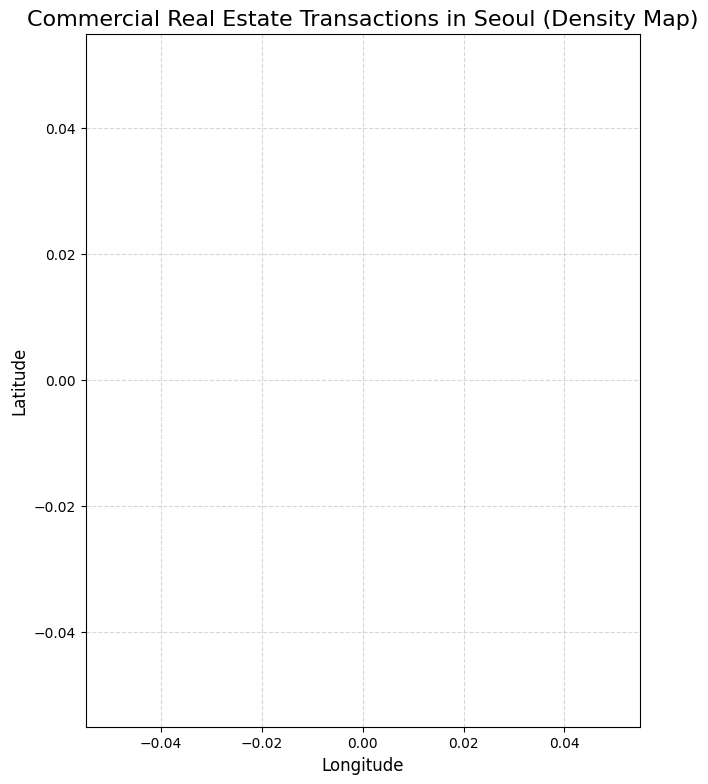


💡 붉은색이 진할수록 상업용 부동산 거래가 활발했던 상권입니다.


In [ ]:
import pandas as pd
import os
import folium
from folium.plugins import HeatMap # 히트맵을 그리기 위한 Folium 플러그인

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
seoul_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")

print("=== 🏙️ 서울시 상업업무 실거래가 밀도 시각화 (Folium Map API) ===\n")

if not os.path.exists(seoul_file):
    print("❌ 서울시 전용 파일이 아직 없습니다. 추출 코드를 먼저 실행해 주세요.")
else:
    df_seoul = pd.read_csv(seoul_file, encoding='cp949')
    df_seoul.dropna(subset=['위도', '경도'], inplace=True)
    print(f"✅ 총 {len(df_seoul):,}건의 데이터를 실제 지도 위에 렌더링합니다...")

    # 1. 서울 중심 좌표를 기준으로 실제 지도 캔버스 생성
    seoul_center = [37.560840, 126.985735]
    # 'CartoDB Positron' 타일을 사용하면 지도가 옅은 회색으로 나와서 데이터가 훨씬 잘 보입니다.
    m1 = folium.Map(location=seoul_center, zoom_start=11, tiles='CartoDB Positron')

    # 2. 히트맵(밀도) 레이어 데이터 생성 및 추가
    heat_data = [[row['위도'], row['경도']] for index, row in df_seoul.iterrows()]
    HeatMap(heat_data, radius=14, blur=10, gradient={0.4: 'yellow', 0.65: 'orange', 1: 'red'}).addTo(m1)

    # 3. 지도 출력 (마우스 휠로 확대/축소 가능)
    display(m1)
    print("\n💡 붉은색이 진할수록 상업용 부동산 거래가 활발했던 상권입니다.")

# 🔗 Merging Subway Inflow/Outflow and Coordinate Data
Aligns and merges subway passenger volume with coordinate data, resolving station naming discrepancies (e.g. 'Gangnam' vs 'Gangnam Station').


In [8]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
ridership_file = os.path.join(base_path, "Seoul_subway_data_2015_2026.csv")
location_file = os.path.join(base_path, "subway_location_data_2015_2026.csv")
output_subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 승하차 및 좌표 데이터 병합 시작 ===\n")

# 1. 파일 로드 (인코딩 자동 대처)
def load_csv(file_path):
    try:
        return pd.read_csv(file_path, encoding='cp949')
    except:
        return pd.read_csv(file_path, encoding='utf-8')

df_rider = load_csv(ridership_file)
df_loc = load_csv(location_file)

print(f"▶ 승하차 원본: {len(df_rider):,}건 / 좌표 원본: {len(df_loc):,}건")

# 2. 역명 정제 로직 (매칭률을 극대화하기 위한 필수 과정)
# - 두 데이터 모두 끝에 붙은 '역' 글자를 제거 ('강남역' -> '강남')
# - 괄호 안의 부역명 제거 ('서울역(150)' -> '서울')
def clean_station_name(name):
    name = str(name).split('(')[0] # 괄호 앞부분만 추출
    if name.endswith('역'):
        name = name[:-1]
    return name.strip()

df_rider['검색용역명'] = df_rider['지하철역'].apply(clean_station_name)
df_loc['검색용역명'] = df_loc['지하철역'].apply(clean_station_name)

# 좌표 데이터에서 중복 역명 제거 (호선이 달라도 환승역은 좌표가 비슷하므로 역명 기준 1개만 남김)
df_loc_unique = df_loc.drop_duplicates(subset=['검색용역명'])

# 3. 데이터 병합 (Left Join: 승하차 데이터에 좌표를 갖다 붙임)
df_merged = pd.merge(df_rider, df_loc_unique[['검색용역명', 'x좌표', 'y좌표']],
                     on='검색용역명', how='left')

# 4. 마무리 (불필요한 임시 컬럼 삭제 및 이름 변경)
df_merged.drop(columns=['검색용역명'], inplace=True)
df_merged.rename(columns={'x좌표': '위도', 'y좌표': '경도'}, inplace=True) # 공공데이터 x,y 표기 기준 반영

# 5. 저장
df_merged.to_csv(output_subway_file, index=False, encoding='cp949')
print(f"\n✅ 병합 성공! 새로운 파일로 저장되었습니다: {output_subway_file}")

=== 🚇 지하철 승하차 및 좌표 데이터 병합 시작 ===



FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/Seoul_subway_data_2015_2026.csv'

# 🔎 Verification of Merged Subway Data
Checks for any coordinate-matching errors due to unique station names and validates merge completeness.


In [13]:
import pandas as pd
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 병합된 지하철 데이터 무결성 검증 ===\n")

df_merged = pd.read_csv(merged_file, encoding='cp949')
total_rows = len(df_merged)

# 1. 결측치(좌표 매칭 실패) 확인
missing_coords = df_merged['위도'].isnull()
missing_count = missing_coords.sum()

print(f"▶ 전체 승하차 데이터: {total_rows:,}건")
print(f"▶ 좌표 매칭 성공: {total_rows - missing_count:,}건 ({(total_rows - missing_count)/total_rows*100:.2f}%)")
print(f"▶ 좌표 매칭 실패: {missing_count:,}건")

if missing_count > 0:
    # 매칭에 실패한 역 이름들 확인
    failed_stations = df_merged[missing_coords]['지하철역'].unique()
    print(f"\n⚠️ [참고] 좌표를 찾지 못한 역 (총 {len(failed_stations)}개):")
    # 최대 15개까지만 출력
    print(failed_stations[:15], "..." if len(failed_stations) > 15 else "")
    print(" (신설역이거나 좌표 파일에 누락된 역일 수 있으며, 분석에 큰 지장은 없습니다.)\n")

display(df_merged.head(3))

=== 📊 병합된 지하철 데이터 무결성 검증 ===

▶ 전체 승하차 데이터: 81,648건
▶ 좌표 매칭 성공: 80,963건 (99.16%)
▶ 좌표 매칭 실패: 685건

⚠️ [참고] 좌표를 찾지 못한 역 (총 1개):
['서울역'] 
 (신설역이거나 좌표 파일에 누락된 역일 수 있으며, 분석에 큰 지장은 없습니다.)



,사용월,호선명,지하철역,04시-05시 승차인원,04시-05시 하차인원,05시-06시 승차인원,05시-06시 하차인원,06시-07시 승차인원,06시-07시 하차인원,07시-08시 승차인원,...,00시-01시 하차인원,01시-02시 승차인원,01시-02시 하차인원,02시-03시 승차인원,02시-03시 하차인원,03시-04시 승차인원,03시-04시 하차인원,작업일자,위도,경도
0,201501,1호선,동대문,413.0,7.0,13701.0,1956.0,10907.0,7588.0,16633.0,...,5095.0,3.0,41.0,0.0,0.0,0.0,0.0,20151223.0,37.571767,127.011257
1,201501,1호선,동묘앞,123.0,3.0,2104.0,911.0,2814.0,3042.0,5815.0,...,3381.0,2.0,251.0,0.0,0.0,0.0,0.0,20151223.0,37.573597,127.017139
2,201501,1호선,서울역,1163.0,35.0,12983.0,10938.0,19926.0,57836.0,60421.0,...,8682.0,7.0,532.0,0.0,0.0,0.0,0.0,20151223.0,NaN,NaN


# (Unused) 🎈 Subway Passenger Inflow Bubble Map Visualization
Visualizes passenger volume scale using proportional bubble sizes on the map.


=== 🚇 지하철 유동인구 버블(Bubble) 지도 시각화 ===

✅ 총 600개 역의 유동인구를 지도에 매핑합니다...


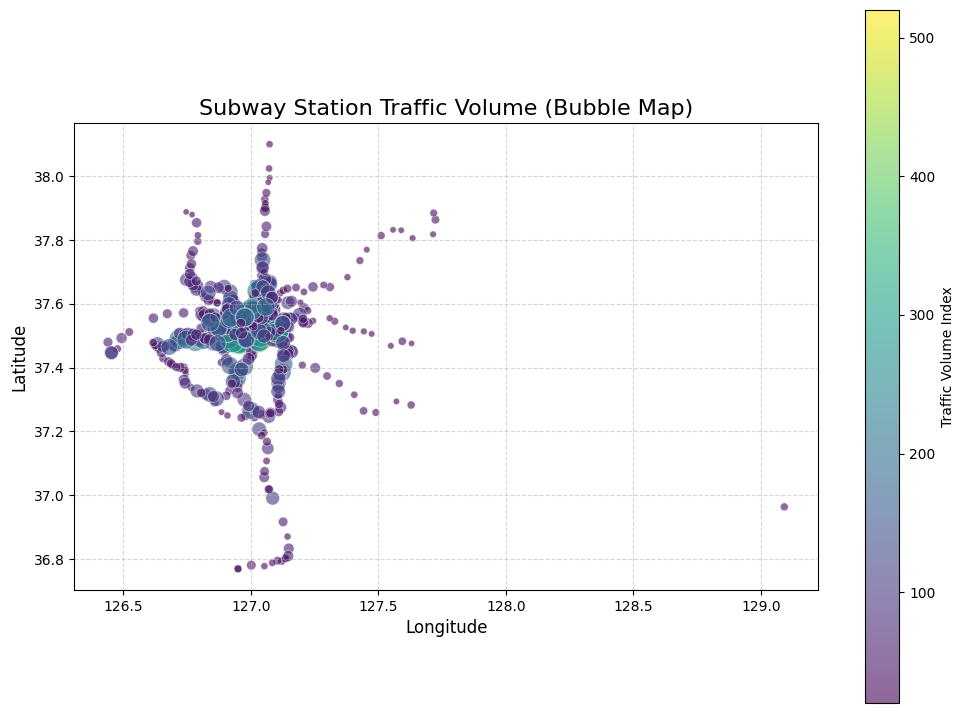


💡 원의 크기가 크고 노란색에 가까울수록 평균 유동인구가 많은 핵심 역세권입니다.


In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 유동인구 버블(Bubble) 지도 시각화 ===\n")

df = pd.read_csv(merged_file, encoding='cp949')
df.dropna(subset=['위도', '경도'], inplace=True) # 좌표 있는 데이터만 남김

# 1. 시간대별 모든 승하차 인원 컬럼 찾기 (숫자형 데이터)
people_cols = [col for col in df.columns if '승차' in col or '하차' in col]

# 2. 각 행별(월별/역별) 총 유동인구 합계 계산
df['총_유동인구'] = df[people_cols].sum(axis=1)

# 3. 역별 평균 유동인구 요약 (시각화를 위해 역 1개당 1줄로 압축)
station_summary = df.groupby(['지하철역', '위도', '경도'])['총_유동인구'].mean().reset_index()

# 4. 버블 크기 정규화 (원이 너무 크거나 작아지지 않게 조정)
sizes = station_summary['총_유동인구']
sizes_normalized = (sizes - sizes.min()) / (sizes.max() - sizes.min())
bubble_sizes = sizes_normalized * 500 + 20 # 최소 크기 20, 최대 크기 520

print(f"✅ 총 {len(station_summary):,}개 역의 유동인구를 지도에 매핑합니다...")

plt.figure(figsize=(12, 9))
scatter = plt.scatter(station_summary['경도'], station_summary['위도'],
                      s=bubble_sizes, alpha=0.6, c=bubble_sizes,
                      cmap='viridis', edgecolors='white', linewidth=0.5)

plt.title('Subway Station Traffic Volume (Bubble Map)', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.colorbar(scatter, label='Traffic Volume Index')
plt.grid(True, linestyle='--', alpha=0.5)

plt.gca().set_aspect(1.25)
plt.show()
print("\n💡 원의 크기가 크고 노란색에 가까울수록 평균 유동인구가 많은 핵심 역세권입니다.")

## 📈 [Cell 4 Upgrade] Subway Passenger Volume Time-Series Interactive Visualization
Creates interactive year-selection boxes to dynamically redraw the bubble map based on selected time periods.


In [ ]:
import pandas as pd
import os
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 유동인구 다차원(시계열+시간대) 시각화 (Folium Map API) ===\n")

if not os.path.exists(merged_file):
    print("❌ 병합된 지하철 데이터 파일이 없습니다. [셀 2]를 먼저 실행해 주세요.")
else:
    df = pd.read_csv(merged_file, encoding='cp949')
    df.dropna(subset=['위도', '경도'], inplace=True)

    df['사용월_str'] = df['사용월'].astype(str)
    df['연도'] = df['사용월_str'].str[:4]
    df['월'] = df['사용월_str'].str[4:6].astype(int)
    df['분기'] = ((df['월'] - 1) // 3 + 1).astype(str) + 'Q'

    people_cols = [col for col in df.columns if '승차' in col or '하차' in col]

    time_groups = {
        '새벽 (04~07시)': ['04시', '05시', '06시'],
        '아침출근 (07~10시)': ['07시', '08시', '09시'],
        '낮/점심 (10~17시)': ['10시', '11시', '12시', '13시', '14시', '15시', '16시'],
        '저녁퇴근 (17~20시)': ['17시', '18시', '19시'],
        '밤/심야 (20~04시)': ['20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']
    }

    df['전체 시간대'] = df[people_cols].sum(axis=1)
    for group_name, prefixes in time_groups.items():
        cols = [col for col in people_cols if any(col.startswith(p) for p in prefixes)]
        df[group_name] = df[cols].sum(axis=1)

    year_list = sorted(df['연도'].unique())
    quarter_list = ['전체', '1Q', '2Q', '3Q', '4Q']
    time_list = ['전체 시간대'] + list(time_groups.keys())

    year_dropdown = widgets.Dropdown(options=year_list, value=year_list[-1], description='📆 연도:')
    quarter_dropdown = widgets.Dropdown(options=quarter_list, value='전체', description='⏱️ 분기:')
    time_dropdown = widgets.Dropdown(options=time_list, value='전체 시간대', description='⏰ 시간대:')

    # 지도가 깜빡이지 않도록 출력 영역 고정
    out = widgets.Output()

    def draw_interactive_map(target_year, target_quarter, target_time):
        with out:
            clear_output(wait=True)
            cond = (df['연도'] == target_year)
            if target_quarter != '전체': cond = cond & (df['분기'] == target_quarter)
            filtered_df = df[cond]

            if filtered_df.empty:
                print(f"❌ {target_year}년 {target_quarter}의 데이터가 존재하지 않습니다.")
                return

            station_summary = filtered_df.groupby(['지하철역', '위도', '경도'])[target_time].mean().reset_index()

            m = folium.Map(location=[37.560840, 126.985735], zoom_start=11, tiles='CartoDB Positron')

            sizes = station_summary[target_time]
            if sizes.max() > sizes.min():
                radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 25 + 5
            else:
                radiuses = [10] * len(station_summary)

            # 지도에 파란색 버블(역) 추가
            for (_, row), radius in zip(station_summary.iterrows(), radiuses):
                folium.CircleMarker(
                    location=[row['위도'], row['경도']],
                    radius=radius,
                    color='#3186cc',
                    weight=1,
                    fill=True,
                    fill_color='#3186cc',
                    fill_opacity=0.5,
                    tooltip=f"<b>{row['지하철역']}역</b><br>평균 유동인구: {int(row[target_time]):,}명"
                ).addTo(m)

            display(m)

    print("👇 연도, 분기, 시간대를 조작하여 상권을 분석해 보세요! (마우스를 원 위에 올리면 상세 정보가 나옵니다)\n")
    display(widgets.HBox([year_dropdown, quarter_dropdown, time_dropdown]))
    display(out)

    def on_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            draw_interactive_map(year_dropdown.value, quarter_dropdown.value, time_dropdown.value)

    year_dropdown.observe(on_change)
    quarter_dropdown.observe(on_change)
    time_dropdown.observe(on_change)

    draw_interactive_map(year_dropdown.value, quarter_dropdown.value, time_dropdown.value)

=== 🚇 지하철 유동인구 다차원(시계열+시간대) 시각화 (Folium Map API) ===

👇 연도, 분기, 시간대를 조작하여 상권을 분석해 보세요! (마우스를 원 위에 올리면 상세 정보가 나옵니다)



Output()

# 🚇 [Cell 4 Final] Top 100 Subway Stations by Alighting Inflow
Visualizes the top 100 subway stations with the highest alighting volume.


In [14]:
import pandas as pd
import os
import folium
import ipywidgets as widgets
from IPython.display import display, clear_output

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
merged_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🚇 지하철 하차(상권 유입) 인구 Top 100 분석 ===\n")

if not os.path.exists(merged_file):
    print("❌ 병합된 지하철 데이터 파일이 없습니다. 이전 셀을 먼저 실행해 주세요.")
else:
    # 1. 데이터 로드
    df = pd.read_csv(merged_file, encoding='cp949')
    df.dropna(subset=['위도', '경도'], inplace=True)

    # 2. 연도 파생 변수 생성 (분기 제외)
    df['연도'] = df['사용월'].astype(str).str[:4]

    # 3. '하차' 인원 컬럼만 추출 (승차 제외)
    alighting_cols = [col for col in df.columns if '하차' in col]

    time_groups = {
        '새벽 (04~07시)': ['04시', '05시', '06시'],
        '아침출근 (07~10시)': ['07시', '08시', '09시'],
        '낮/점심 (10~17시)': ['10시', '11시', '12시', '13시', '14시', '15시', '16시'],
        '저녁퇴근 (17~20시)': ['17시', '18시', '19시'],
        '밤/심야 (20~04시)': ['20시', '21시', '22시', '23시', '00시', '01시', '02시', '03시']
    }

    # 4. 시간대별 '하차' 인구 합계 계산
    df['전체 시간대'] = df[alighting_cols].sum(axis=1)

    for group_name, prefixes in time_groups.items():
        # 해당 시간대의 '하차' 컬럼만 선별하여 합산
        cols = [col for col in alighting_cols if any(col.startswith(p) for p in prefixes)]
        df[group_name] = df[cols].sum(axis=1)

    # 5. 위젯 목록 설정
    year_list = sorted(df['연도'].unique())
    time_list = ['전체 시간대'] + list(time_groups.keys())

    year_dropdown = widgets.Dropdown(options=year_list, value=year_list[-1], description='📆 연도:')
    time_dropdown = widgets.Dropdown(options=time_list, value='전체 시간대', description='⏰ 시간대:')

    # 6. 지도 출력 영역
    out = widgets.Output()

    def draw_interactive_map(target_year, target_time):
        with out:
            clear_output(wait=True)

            # 연도 필터링
            filtered_df = df[df['연도'] == target_year]

            if filtered_df.empty:
                print(f"❌ {target_year}년의 데이터가 존재하지 않습니다.")
                return

            # 역별 평균 하차 인구 계산
            station_summary = filtered_df.groupby(['지하철역', '위도', '경도'])[target_time].mean().reset_index()

            # [핵심] 상위 100개 역만 추출 (Top 100)
            top_100_stations = station_summary.nlargest(100, target_time).reset_index(drop=True)

            # 지도 캔버스 생성
            m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

            # 버블 크기 정규화 (가장 하차인원이 많은 역이 가장 큰 원을 가짐)
            sizes = top_100_stations[target_time]
            if sizes.max() > sizes.min():
                # 최소 크기 6, 최대 크기 35
                radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 29 + 6
            else:
                radiuses = [15] * len(top_100_stations)

            # 지도에 파란색 버블(Top 100 역) 추가
            for idx, row in top_100_stations.iterrows():
                # 순위 표시 텍스트
                rank = idx + 1

                # add_to() 로 오타 수정 완료
                folium.CircleMarker(
                    location=[row['위도'], row['경도']],
                    radius=radiuses[idx],
                    color='#e74c3c' if rank <= 10 else '#3498db', # Top 10은 빨간색, 나머지는 파란색
                    weight=1.5 if rank <= 10 else 1,
                    fill=True,
                    fill_color='#e74c3c' if rank <= 10 else '#3498db',
                    fill_opacity=0.6,
                    tooltip=f"<b>{rank}위: {row['지하철역']}역</b><br>평균 하차: {int(row[target_time]):,}명"
                ).add_to(m)

            display(m)
            print(f"💡 {target_year}년 [{target_time}] 기준 - 하차 인구가 가장 많은 Top 100 역입니다. (Top 10은 붉은색)")

    print("👇 연도와 시간대를 선택하여 '어느 시간대에 사람들이 상권으로 몰리는지' 파악해 보세요!\n")
    display(widgets.HBox([year_dropdown, time_dropdown]))
    display(out)

    # 위젯 변경 감지기
    def on_change(change):
        if change['type'] == 'change' and change['name'] == 'value':
            draw_interactive_map(year_dropdown.value, time_dropdown.value)

    year_dropdown.observe(on_change)
    time_dropdown.observe(on_change)

    # 초기 화면 그리기
    draw_interactive_map(year_dropdown.value, time_dropdown.value)

=== 🚇 지하철 하차(상권 유입) 인구 Top 100 분석 ===

👇 연도와 시간대를 선택하여 '어느 시간대에 사람들이 상권으로 몰리는지' 파악해 보세요!



Output()

# 🚌 [Cell 1] Safe Loading of Large Seoul Bus Alighting Datasets


In [15]:
import pandas as pd
import os
from google.colab import drive

# 1. 구글 드라이브 마운트
drive.mount('/content/drive')

# 2. 파일 경로 설정 (이전 경로 유지)
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
bus_file = os.path.join(base_path, "seoul_bus_daily_alighting.csv")

print("=== 🚌 대용량 버스 하차 데이터 로드 시작 ===\n")

if not os.path.exists(bus_file):
    print(f"❌ 파일을 찾을 수 없습니다 경로를 확인해주세요: {bus_file}")
else:
    print("파일을 읽어오는 중입니다. 용량이 커서(약 900MB) 약 1~2분 정도 소요될 수 있습니다...")

    # 3. [핵심] 메모리 최적화를 위한 데이터 타입(dtype) 강제 지정
    # 이렇게 지정해주면 코랩 메모리 초과(OOM) 다운을 완벽하게 방지할 수 있습니다.
    optimized_dtypes = {
        '년도': 'int16',            # 2023~2026 같은 작은 정수는 int16으로 충분함
        '일자': 'int32',            # 20230101 등 8자리 정수형
        '정류장역이름': 'object',
        '일별하차인원': 'int32',
        'X좌표(위도)': 'float32',  # 소수점 6자리 좌표는 float32로도 정밀도 유지 가능
        'Y좌표(경도)': 'float32'
    }

    # 4. 데이터 로드 (스캐너에서 확인된 utf-8-sig 인코딩 적용)
    df_bus = pd.read_csv(bus_file, encoding='utf-8-sig', dtype=optimized_dtypes)

    # 5. 결과 확인
    print("\n✅ 데이터 로드 완료!")
    print(f"▶ 총 데이터 건수: {len(df_bus):,}건")

    # 메모리 사용량 체크
    mem_usage = df_bus.memory_usage(deep=True).sum() / (1024**2)
    print(f"▶ 현재 메모리 사용량: {mem_usage:.2f} MB (최적화 적용)\n")

    display(df_bus.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== 🚌 대용량 버스 하차 데이터 로드 시작 ===

❌ 파일을 찾을 수 없습니다 경로를 확인해주세요: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/seoul_bus_daily_alighting.csv


# 🗺️ [Cell 2] Top 1000 Seoul Bus Stops by Alighting Inflow (Folium)


In [ ]:
import pandas as pd
import folium

print("=== 🚌 서울 버스 하차 인원 Top 1000 지도 시각화 ===\n")

# 메모리에 df_bus가 있는지 확인 (이전 셀 실행 여부)
if 'df_bus' not in globals():
    print("❌ 메모리에 버스 데이터가 없습니다. 이전의 [셀 1] 로드 코드를 먼저 실행해 주세요.")
else:
    print("▶ 데이터를 집계하고 있습니다. 잠시만 기다려주세요...")

    # 1. 정류장별 '평균 일별 하차 인원' 계산
    # 동일한 정류장 이름과 좌표를 가진 데이터를 묶어서 평균을 냅니다.
    stop_summary = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index()

    # 2. 하차 인원 기준 Top 1000 추출
    top_1000_stops = stop_summary.nlargest(1000, '일별하차인원').reset_index(drop=True)

    print(f"✅ Top 1000 정류장 추출 완료! (1위: {top_1000_stops.loc[0, '정류장역이름']} - 평균 {int(top_1000_stops.loc[0, '일별하차인원']):,}명)")
    print("▶ 지도를 렌더링하고 있습니다. 점이 많아 약 5~10초 정도 소요될 수 있습니다...")

    # 3. 옅은 회색 지도 캔버스 생성
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    # 4. 버블 크기 정규화용 최소/최대값
    sizes = top_1000_stops['일별하차인원']
    min_size, max_size = sizes.min(), sizes.max()

    # 5. Top 1000 지도에 마커 추가
    for idx, row in top_1000_stops.iterrows():
        rank = idx + 1

        # 순위에 따른 색상 및 크기 차등 적용 (가시성 극대화)
        if rank <= 10:
            color = '#e74c3c' # 빨간색 (최상위 Top 10)
            radius = 14
            weight = 2
            fill_opacity = 0.8
        elif rank <= 100:
            color = '#f39c12' # 주황색 (Top 11 ~ 100)
            radius = 8
            weight = 1.5
            fill_opacity = 0.7
        else:
            color = '#3498db' # 파란색 (Top 101 ~ 1000)
            # 101~1000위는 데이터 크기에 비례하여 3~6 사이의 작은 크기로 설정
            radius = ((row['일별하차인원'] - min_size) / (max_size - min_size)) * 3 + 3
            weight = 0.5
            fill_opacity = 0.4

        # 지도에 원 그리기
        folium.CircleMarker(
            location=[row['X좌표(위도)'], row['Y좌표(경도)']],
            radius=radius,
            color=color,
            weight=weight,
            fill=True,
            fill_color=color,
            fill_opacity=fill_opacity,
            tooltip=f"<b>{rank}위: {row['정류장역이름']}</b><br>평균 하차: {int(row['일별하차인원']):,}명"
        ).add_to(m)

    display(m)
    print("\n💡 [분석 팁]")
    print(" - 🔴 빨간색 원: 최상위 핵심 유동인구 지역 (Top 1~10)")
    print(" - 🟠 주황색 원: 대형 거점 상권 및 환승 구역 (Top 11~100)")
    print(" - 🔵 파란색 원: 일반적인 활성화 정류장 (Top 101~1000)")

=== 🚌 서울 버스 하차 인원 Top 1000 지도 시각화 ===

▶ 데이터를 집계하고 있습니다. 잠시만 기다려주세요...
✅ Top 1000 정류장 추출 완료! (1위: 구로디지털단지역 - 평균 11,434명)
▶ 지도를 렌더링하고 있습니다. 점이 많아 약 5~10초 정도 소요될 수 있습니다...



💡 [분석 팁]
 - 🔴 빨간색 원: 최상위 핵심 유동인구 지역 (Top 1~10)
 - 🟠 주황색 원: 대형 거점 상권 및 환승 구역 (Top 11~100)
 - 🔵 파란색 원: 일반적인 활성화 정류장 (Top 101~1000)


# 🌟 [Cell 3] Core Commercial Zone Fusion: Subway Top 100 × Bus Top 1000 Intersection Analysis
Spatially intersects subway and bus datasets to generate and map the combined transit inflow.


In [ ]:
import pandas as pd
import numpy as np
import os
import folium

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
# bus_file 은 메모리의 df_bus를 활용하거나 없으면 다시 로드
output_file = os.path.join(base_path, "핵심상권_교차_Top100.csv")

print("=== 🌟 핵심 상권 융합: 지하철 Top 100 × 버스 Top 1000 ===\n")

if not os.path.exists(subway_file) or 'df_bus' not in globals():
    print("❌ 이전 단계의 지하철 또는 버스 데이터가 준비되지 않았습니다.")
else:
    print("▶ 데이터를 집계하고 공간 거리를 계산하고 있습니다. 잠시만 기다려주세요...\n")

    # ---------------------------------------------------------
    # 1. 지하철 Top 100 추출 (2026년 기준)
    # ---------------------------------------------------------
    df_sub = pd.read_csv(subway_file, encoding='cp949')
    df_sub.dropna(subset=['위도', '경도'], inplace=True)
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    # 2026년 데이터로 한정 (최신 트렌드 반영)
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()

    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026['일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    sub_summary = df_sub_2026.groupby(['지하철역', '위도', '경도'])['일평균_하차'].mean().reset_index()
    top100_sub = sub_summary.nlargest(100, '일평균_하차').reset_index(drop=True)

    # ---------------------------------------------------------
    # 2. 버스 Top 1000 추출
    # ---------------------------------------------------------
    bus_summary = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index()
    top1000_bus = bus_summary.nlargest(1000, '일별하차인원').reset_index(drop=True)

    # ---------------------------------------------------------
    # 3. 공간 병합 (Spatial Join): 하버사인(Haversine) 거리 계산
    # ---------------------------------------------------------
    def haversine(lat1, lon1, lat2, lon2):
        R = 6371.0 # 지구 반지름 (km)
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
        c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))
        return R * c * 1000 # 미터(m) 단위로 반환

    cross_data = []

    # 지하철역 하나당 1000개의 버스 정류장과의 거리를 계산
    for _, sub_row in top100_sub.iterrows():
        sub_lat, sub_lon = sub_row['위도'], sub_row['경도']

        # 벡터 연산으로 1000개 거리 한 번에 계산 (고속)
        distances = haversine(sub_lat, sub_lon, top1000_bus['X좌표(위도)'].values, top1000_bus['Y좌표(경도)'].values)

        # 반경 300m 이내에 들어오는 버스 정류장만 필터링
        close_buses = top1000_bus[distances <= 300]

        if not close_buses.empty:
            cross_data.append({
                '지하철역': sub_row['지하철역'],
                '지하철_위도': sub_lat,
                '지하철_경도': sub_lon,
                '지하철_일평균하차': sub_row['일평균_하차'],
                '주변_핵심버스정류장_수': len(close_buses),
                '주변_버스_총하차인원': close_buses['일별하차인원'].sum(),
                # 시각화를 위해 매칭된 버스 정류장 목록 리스트 저장
                'matched_buses': close_buses[['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)', '일별하차인원']].to_dict('records')
            })

    # 4. 결과 데이터프레임 생성 및 정렬 (버스와의 시너지가 가장 높은 순)
    df_cross = pd.DataFrame(cross_data)
    df_cross['통합_유동인구_지수'] = df_cross['지하철_일평균하차'] + df_cross['주변_버스_총하차인원']
    df_cross = df_cross.sort_values(by='통합_유동인구_지수', ascending=False).reset_index(drop=True)

    # 리스트 컬럼은 파일 저장을 위해 제외하고 순수 데이터만 저장
    save_cols = ['지하철역', '지하철_위도', '지하철_경도', '지하철_일평균하차', '주변_핵심버스정류장_수', '주변_버스_총하차인원', '통합_유동인구_지수']
    df_cross[save_cols].to_csv(output_file, index=False, encoding='cp949')
    print(f"✅ 교차 분석 완료! 반경 300m 매칭 파일이 저장되었습니다: {output_file}")

    # ---------------------------------------------------------
    # 4. 지도 시각화 (오버레이)
    # ---------------------------------------------------------
    print("▶ 융합 지도를 렌더링합니다...")
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    # 매칭된 곳만 지도에 그리기
    for idx, row in df_cross.iterrows():
        # [레이어 1] 지하철역 (반투명한 큰 파란색 원)
        folium.CircleMarker(
            location=[row['지하철_위도'], row['지하철_경도']],
            radius=20 if idx < 10 else 12, # 융합 Top 10은 더 크게
            color='#3498db',
            weight=2,
            fill=True,
            fill_color='#3498db',
            fill_opacity=0.3,
            tooltip=f"<b>🏆 {idx+1}위: {row['지하철역']}역 반경 300m</b><br>지하철 하차: {int(row['지하철_일평균하차']):,}명<br>버스 하차 합계: {int(row['주변_버스_총하차인원']):,}명"
        ).add_to(m)

        # [레이어 2] 매칭된 버스 정류장들 (지하철역 주변의 붉은 점들)
        for bus in row['matched_buses']:
            folium.CircleMarker(
                location=[bus['X좌표(위도)'], bus['Y좌표(경도)']],
                radius=4,
                color='#e74c3c',
                weight=1,
                fill=True,
                fill_color='#e74c3c',
                fill_opacity=0.8,
                tooltip=f"<b>(버스) {bus['정류장역이름']}</b><br>평균 하차: {int(bus['일별하차인원']):,}명"
            ).add_to(m)

    display(m)
    print("\n💡 [지도 해석 팁]")
    print(" - 🔵 파란색 큰 원: 지하철 하차 Top 100 중 버스와 교차하는 핵심 역세권")
    print(" - 🔴 빨간색 작은 점: 해당 역 반경 300m 이내에 있는 버스 하차 Top 1000 정류장")
    print(" - 두 색상이 뭉쳐있는 곳이 대중교통 유입이 폭발하는 '초대형 융합 상권'입니다.")

=== 🌟 핵심 상권 융합: 지하철 Top 100 × 버스 Top 1000 ===

▶ 데이터를 집계하고 공간 거리를 계산하고 있습니다. 잠시만 기다려주세요...

✅ 교차 분석 완료! 반경 300m 매칭 파일이 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/핵심상권_교차_Top100.csv
▶ 융합 지도를 렌더링합니다...



💡 [지도 해석 팁]
 - 🔵 파란색 큰 원: 지하철 하차 Top 100 중 버스와 교차하는 핵심 역세권
 - 🔴 빨간색 작은 점: 해당 역 반경 300m 이내에 있는 버스 하차 Top 1000 정류장
 - 두 색상이 뭉쳐있는 곳이 대중교통 유입이 폭발하는 '초대형 융합 상권'입니다.


# 🌟 [Cell 3 Final] Core Transit-Fused Commercial Zones Extraction & Map Visualization (Highlighting Top 10)


In [ ]:
import pandas as pd
import numpy as np
import os
import folium

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")
output_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")

print("=== 🌟 대중교통 융합 상권 분석 (Top 10 강조) ===\n")

if not os.path.exists(subway_file) or 'df_bus' not in globals():
    print("❌ 이전 단계의 데이터가 메모리에 없습니다. [셀 1]과 지하철 데이터 코드를 확인해 주세요.")
else:
    print("▶ 두 데이터를 융합하고 있습니다. 잠시만 기다려주세요...\n")

    # 1. 지하철 Top 100 추출 (2026년 하차 기준)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026['일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)
    top100_sub = df_sub_2026.groupby(['지하철역', '위도', '경도'])['일평균_하차'].mean().reset_index().nlargest(100, '일평균_하차').reset_index(drop=True)

    # 2. 버스 Top 1000 추출
    top1000_bus = df_bus.groupby(['정류장역이름', 'X좌표(위도)', 'Y좌표(경도)'])['일별하차인원'].mean().reset_index().nlargest(1000, '일별하차인원').reset_index(drop=True)

    # 3. 공간 병합 (하버사인 거리 계산 - 반경 300m 이내)
    def haversine(lat1, lon1, lat2, lon2):
        lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
        a = np.sin((lat2 - lat1)/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1)/2)**2
        return 6371.0 * (2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))) * 1000

    cross_data = []
    for _, sub_row in top100_sub.iterrows():
        distances = haversine(sub_row['위도'], sub_row['경도'], top1000_bus['X좌표(위도)'].values, top1000_bus['Y좌표(경도)'].values)
        close_buses = top1000_bus[distances <= 300]

        if not close_buses.empty:
            cross_data.append({
                '핵심_지하철역': sub_row['지하철역'],
                '위도': sub_row['위도'],
                '경도': sub_row['경도'],
                '지하철_하차인원': sub_row['일평균_하차'],
                '연계_버스정류장수': len(close_buses),
                '버스_하차인원': close_buses['일별하차인원'].sum(),
                '통합_유동인구': sub_row['일평균_하차'] + close_buses['일별하차인원'].sum()
            })

    # 4. 통합 데이터 정렬 및 별도 파일 저장
    df_cross = pd.DataFrame(cross_data).sort_values(by='통합_유동인구', ascending=False).reset_index(drop=True)
    df_cross.to_csv(output_file, index=False, encoding='cp949')

    print(f"✅ 통합 완료! 융합 데이터가 별도 파일로 안전하게 저장되었습니다: {output_file}")
    print(f"🏆 1위 상권: {df_cross.loc[0, '핵심_지하철역']}역 일대 (통합 유동인구: {int(df_cross.loc[0, '통합_유동인구']):,}명)\n")

    # 5. Folium 지도 시각화 (Top 10 컬러 강조 적용)
    print("▶ 융합 지도를 렌더링합니다...")
    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11.5, tiles='CartoDB Positron')

    for idx, row in df_cross.iterrows():
        rank = idx + 1

        # 🚨 [핵심] 순위에 따른 색상 및 크기 분기 처리
        if rank <= 10:
            zone_color = '#e74c3c'  # 🔴 붉은색 (최상위 Top 10)
            zone_radius = 18
            zone_weight = 2
            zone_opacity = 0.7
        else:
            zone_color = '#3498db'  # 🔵 푸른색 (11위 이하)
            zone_radius = 10
            zone_weight = 1
            zone_opacity = 0.5

        # 통합 상권 마커 그리기
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=zone_radius,
            color=zone_color,
            weight=zone_weight,
            fill=True,
            fill_color=zone_color,
            fill_opacity=zone_opacity,
            tooltip=(
                f"<div style='font-size:14px;'>"
                f"<b>🏆 {rank}위: {row['핵심_지하철역']}역 상권</b><br>"
                f"<hr style='margin: 4px 0;'>"
                f"▪ 통합 하차인원: <b>{int(row['통합_유동인구']):,}명</b><br>"
                f"▪ 지하철 기여도: {int(row['지하철_하차인원']):,}명<br>"
                f"▪ 버스 기여도: {int(row['버스_하차인원']):,}명<br>"
                f"▪ 연계 정류장: {row['연계_버스정류장수']}개"
                f"</div>"
            )
        ).add_to(m)

    display(m)
    print("\n💡 [지도 해석 팁]")
    print(" - 🔴 붉은색 대형 원: 서울시 대중교통 유입 최상위 Top 10 (메가 상권)")
    print(" - 🔵 푸른색 소형 원: 그 외 연계가 우수한 주요 환승/상업 거점")
    print(" - 마우스를 원 위에 올리면 지하철과 버스의 정확한 유동인구 기여도를 확인할 수 있습니다.")

=== 🌟 대중교통 융합 상권 분석 (Top 10 강조) ===

▶ 두 데이터를 융합하고 있습니다. 잠시만 기다려주세요...

✅ 통합 완료! 융합 데이터가 별도 파일로 안전하게 저장되었습니다: /content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/대중교통_융합_핵심상권.csv
🏆 1위 상권: 강남역 일대 (통합 유동인구: 2,307,448명)

▶ 융합 지도를 렌더링합니다...



💡 [지도 해석 팁]
 - 🔴 붉은색 대형 원: 서울시 대중교통 유입 최상위 Top 10 (메가 상권)
 - 🔵 푸른색 소형 원: 그 외 연계가 우수한 주요 환승/상업 거점
 - 마우스를 원 위에 올리면 지하철과 버스의 정확한 유동인구 기여도를 확인할 수 있습니다.


# 📊 [Cell 4] Core Fused Commercial Zones vs. Seoul Average Comparison (Plotly)


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # 1. 기준점(Baseline) : 서울시 일반 평균 계산
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    # 2026년 데이터만 추출 (원본 변경 방지를 위해 .copy() 사용)
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]

    # 🚨 [수정 사항] .loc를 사용하여 경고 메시지 방지
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()
    avg_total = avg_subway + avg_bus

    # 2. 분석 대상 : 융합 상권 Top 10 데이터 로드
    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(10).iloc[::-1].reset_index(drop=True)

    # 3. 그래프 데이터 준비
    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {10-i}위: {name} 상권" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 4. Plotly 누적 막대 그래프 생성
    fig = go.Figure()

    fig.add_trace(go.Bar(y=labels, x=subway_vals, name='지하철 하차인원', orientation='h', marker=dict(color='#3498db')))
    fig.add_trace(go.Bar(y=labels, x=bus_vals, name='주변 버스 하차인원', orientation='h', marker=dict(color='#e74c3c')))

    fig.update_layout(
        title='<b>Top 10 핵심 융합상권 vs 서울시 평균 유동인구 규모</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 합계 (명)',
        height=700,
        template='plotly_white'
    )

    fig.show()
    print("✅ 데이터 분석 및 그래프 시각화가 완료되었습니다!")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===



✅ 데이터 분석 및 그래프 시각화가 완료되었습니다!


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 (수치 라벨 포함) ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # 1. 기준점 및 데이터 준비 (경고 방지를 위해 .loc 사용)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]

    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()

    # 2. 분석 대상 상권 로드
    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(10).iloc[::-1].reset_index(drop=True)

    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {10-i}위: {name}" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 3. Plotly 누적 막대 그래프 (수치 라벨 추가)
    fig = go.Figure()

    # 지하철 막대
    fig.add_trace(go.Bar(
        y=labels, x=subway_vals, name='지하철 하차',
        orientation='h', marker=dict(color='#3498db'),
        text=[f"{int(v):,}" for v in subway_vals], textposition='inside' # 텍스트 추가
    ))

    # 버스 막대
    fig.add_trace(go.Bar(
        y=labels, x=bus_vals, name='주변 버스 하차',
        orientation='h', marker=dict(color='#e74c3c'),
        text=[f"{int(v):,}" for v in bus_vals], textposition='inside' # 텍스트 추가
    ))

    fig.update_layout(
        title='<b>Top 10 핵심 상권 vs 서울시 평균 유동인구</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 (명)',
        height=700,
        template='plotly_white',
        uniformtext_mode='hide', # 너무 좁은 공간은 텍스트 숨김 (깔끔함 유지)
        uniformtext_minsize=9
    )

    fig.show()
    print("✅ 시각화 완료! 막대 내부에서 바로 수치를 확인하세요.")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 (수치 라벨 포함) ===



✅ 시각화 완료! 막대 내부에서 바로 수치를 확인하세요.


In [ ]:
import pandas as pd
import plotly.graph_objects as go
import os

# 1. 파일 경로 설정
base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
fusion_file = os.path.join(base_path, "대중교통_융합_핵심상권.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===\n")

if not os.path.exists(fusion_file) or 'df_bus' not in globals():
    print("❌ 데이터가 없습니다. [셀 1]과 [셀 3]을 먼저 정상적으로 실행해 주세요.")
else:
    # Load Data (이전과 동일)
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub['연도'] = df_sub['사용월'].astype(str).str[:4]
    df_sub_2026 = df_sub[df_sub['연도'] == '2026'].copy()
    alighting_cols = [col for col in df_sub_2026.columns if '하차' in col]
    df_sub_2026.loc[:, '일평균_하차'] = df_sub_2026[alighting_cols].sum(axis=1)

    avg_subway = df_sub_2026.groupby('지하철역')['일평균_하차'].mean().mean()
    avg_bus = df_bus.groupby('정류장역이름')['일별하차인원'].mean().mean()

    df_top10 = pd.read_csv(fusion_file, encoding='cp949').head(10).iloc[::-1].reset_index(drop=True)

    labels = ['[기준] 서울시 일반 평균'] + [f"🏆 {10-i}위: {name}" for i, name in enumerate(df_top10['핵심_지하철역'])]
    subway_vals = [avg_subway] + df_top10['지하철_하차인원'].tolist()
    bus_vals = [avg_bus] + df_top10['버스_하차인원'].tolist()

    # 3. Plotly 누적 막대 그래프 (텍스트 가시성 극대화)
    fig = go.Figure()

    # 지하철 막대 (푸른색)
    fig.add_trace(go.Bar(
        y=labels, x=subway_vals, name='지하철 하차',
        orientation='h', marker=dict(color='#3498db'),
        text=[f"{int(v):,}" for v in subway_vals],
        textposition='auto', # 'auto'로 설정하여 공간에 따라 안팎으로 자동 배치
        texttemplate='%{text}', # 텍스트 템플릿 명시
        textfont=dict(size=11)
    ))

    # 버스 막대 (붉은색)
    fig.add_trace(go.Bar(
        y=labels, x=bus_vals, name='주변 버스 하차',
        orientation='h', marker=dict(color='#e74c3c'),
        text=[f"{int(v):,}" for v in bus_vals],
        textposition='auto', # 'auto'로 설정
        texttemplate='%{text}',
        textfont=dict(size=11)
    ))

    fig.update_layout(
        title='<b>Top 10 핵심 상권 vs 서울시 평균 유동인구 (수치 표시)</b>',
        barmode='stack',
        xaxis_title='일평균 하차 인원 (명)',
        height=700,
        template='plotly_white',
        margin=dict(l=150, r=50, t=80, b=50) # 왼쪽 레이블이 잘리지 않도록 마진 조정
    )

    fig.show()
    print("✅ 지하철과 버스 데이터 수치가 모두 표시되었습니다.")

=== 📊 서울시 평균 대비 융합 핵심상권 유동인구 비교 분석 ===



✅ 지하철과 버스 데이터 수치가 모두 표시되었습니다.


# (Unused) 🗺️ Integrated Visualization: Commercial Transaction Density & Subway Flow Overlay


In [ ]:
import pandas as pd
import os
import folium
from folium.plugins import HeatMap

base_path = "/content/drive/MyDrive/Colab Notebooks/2026/이어드림스쿨6기/dataset/"
real_estate_file = os.path.join(base_path, "상업업무_실거래가_서울_최종.csv")
subway_file = os.path.join(base_path, "지하철_승하차_좌표결합.csv")

print("=== 🗺️ [통합 오버레이] 부동산 실거래가 밀도 & 지하철 유동인구 (Folium Map) ===\n")

if not os.path.exists(real_estate_file) or not os.path.exists(subway_file):
    print("❌ 필요한 데이터 파일이 모두 준비되지 않았습니다.")
else:
    df_real = pd.read_csv(real_estate_file, encoding='cp949').dropna(subset=['위도', '경도'])
    df_sub = pd.read_csv(subway_file, encoding='cp949').dropna(subset=['위도', '경도'])

    people_cols = [col for col in df_sub.columns if '승차' in col or '하차' in col]
    df_sub['총_유동인구'] = df_sub[people_cols].sum(axis=1)
    station_summary = df_sub.groupby(['지하철역', '위도', '경도'])['총_유동인구'].mean().reset_index()

    m = folium.Map(location=[37.560840, 126.985735], zoom_start=11, tiles='CartoDB Positron')

    # [레이어 1] 상권 밀도 (히트맵)
    heat_data = [[row['위도'], row['경도']] for index, row in df_real.iterrows()]
    HeatMap(heat_data, radius=13, blur=10, gradient={0.4: 'yellow', 0.65: 'orange', 1: 'red'}).addTo(m)

    # [레이어 2] 지하철 유동인구 (버블)
    sizes = station_summary['총_유동인구']
    if sizes.max() > sizes.min():
        radiuses = ((sizes - sizes.min()) / (sizes.max() - sizes.min())) * 25 + 4
    else:
        radiuses = [10] * len(station_summary)

    for (_, row), radius in zip(station_summary.iterrows(), radiuses):
        folium.CircleMarker(
            location=[row['위도'], row['경도']],
            radius=radius,
            color='#3186cc',
            weight=1,
            fill=True,
            fill_color='#3186cc',
            fill_opacity=0.4,
            tooltip=f"<b>{row['지하철역']}역</b><br>총 유동인구: {int(row['총_유동인구']):,}명"
        ).addTo(m)

    display(m)
    print("\n💡 붉은색 히트맵은 상업용 매매 활성화 구역, 파란색 원은 지하철 유동인구 규모를 나타냅니다.")
    print("   지도를 확대/축소하거나 마우스를 파란색 원에 올려 역 이름을 확인해 보세요.")

=== 🗺️ [통합 오버레이] 부동산 실거래가 밀도 & 지하철 유동인구 (Folium Map) ===



AttributeError: 'HeatMap' object has no attribute 'addTo'